# Morphological Operations

In [1]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

In [2]:
def show(array1: np.ndarray, array2: np.ndarray, dpi=None) -> None:
    """Plot differences between two boolean 2D numpy arrays.

    Highlights pixels that are on in both arrays (black), removed pixels (red),
    and added pixels (green). Pixels off in both arrays are shown in white.

    Parameters
    ----------
    array1 : np.ndarray
        First boolean 2D array.
    array2 : np.ndarray
        Second boolean 2D array.

    Raises
    ------
    ValueError
        If the input arrays do not have the same shape or are not boolean 2D arrays.

    Notes
    -----
    Requires matplotlib.
    """
    # Validate inputs
    if array1.shape != array2.shape:
        raise ValueError(f"Input arrays must have the same shape, got {array1.shape} and {array2.shape}.")
    if array1.ndim != 2 or array2.ndim != 2:
        raise ValueError("Input arrays must be 2D.")
    if not (np.issubdtype(array1.dtype, np.bool_) and np.issubdtype(array2.dtype, np.bool_)):
        raise ValueError("Input arrays must be of boolean dtype.")

    # Initialize an image with white background
    height, width = array1.shape
    image = np.ones((height, width, 3), dtype=float)

    # Both arrays true -> black
    both_mask = array1 & array2
    image[both_mask] = [0.2, 0.2, 0.2]

    # True in array1, False in array2 -> red (removed)
    removed_mask = array1 & ~array2
    image[removed_mask] = [1.0, 0.0, 0.0]

    # False in array1, True in array2 -> green (added)
    added_mask = ~array1 & array2
    image[added_mask] = [0.0, 1.0, 0.0]

    # Display the result
    fig = plt.figure(figsize=(width, height), dpi=dpi or min(width, height)/100)
    fig.canvas.header_visible = False   # hides “Figure X” bar
    fig.canvas.toolbar_visible = False  # hides the floating toolbar
    fig.canvas.footer_visible = False   # hides the (x,y) readout bar
    ax = fig.add_axes([0,0,1,1])
    ax.imshow(image, interpolation='nearest')
    ax.axis('off')
    plt.show()


## Sample Image Creation

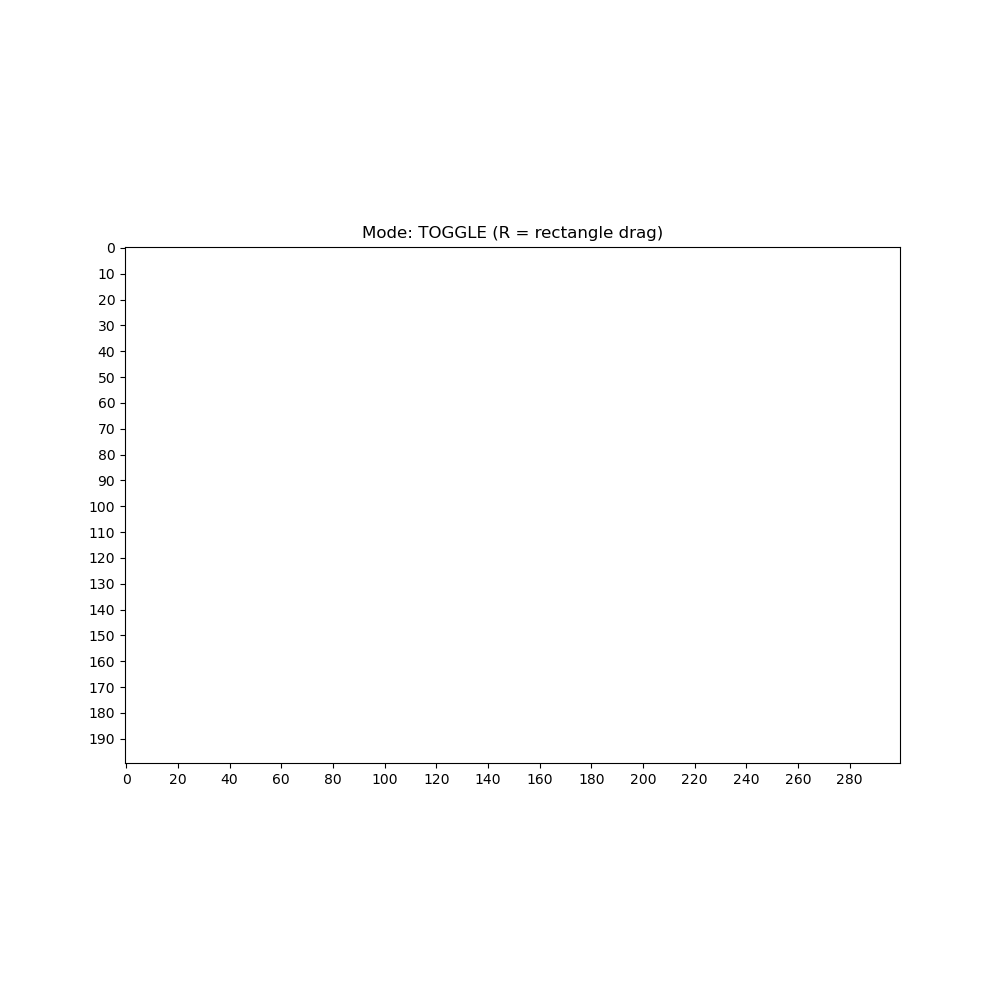

In [3]:
%matplotlib widget
import scishow
editor = scishow.matplotlib.GridEditor2D(rows=200, cols=300)

In [28]:
a=editor.grid

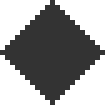

In [39]:
STRUCTURE_CONNECTIVITY = 1
STRUCTURE_ITERATIONS = 10

structure=ndimage.generate_binary_structure(rank=2, connectivity=STRUCTURE_CONNECTIVITY)
structure=ndimage.iterate_structure(structure, iterations=STRUCTURE_ITERATIONS)
show(structure,structure, dpi=5)

## Fill Holes

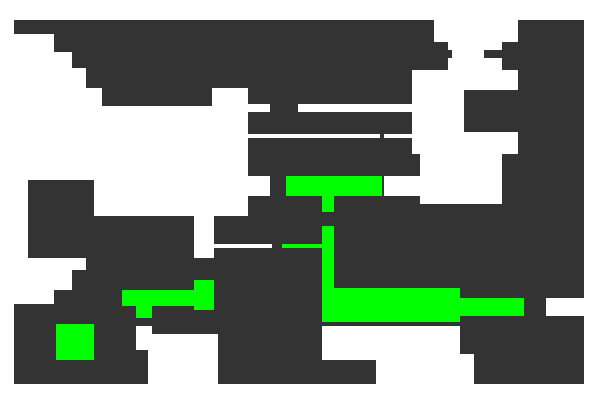

In [30]:
fill_holes = ndimage.binary_fill_holes(
    input=np.logical_not(a),
    structure=structure,
    origin=0
)
show(np.logical_not(a), fill_holes)

## Dilation

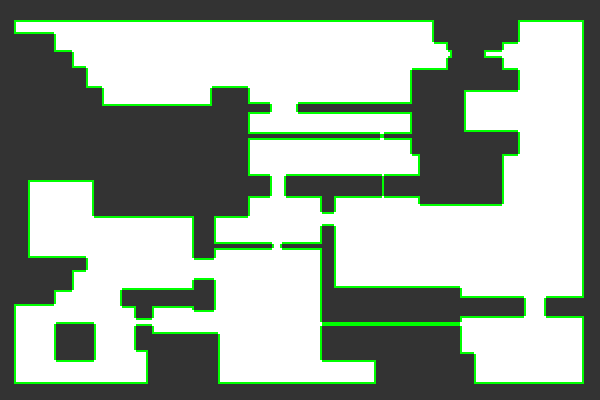

In [31]:
dilation = ndimage.binary_dilation(
    input=a,
    structure=structure,
    iterations=1,
    mask=None,
    border_value=0,
    origin=0,
    brute_force=False
)
show(a, dilation)

## Erosion

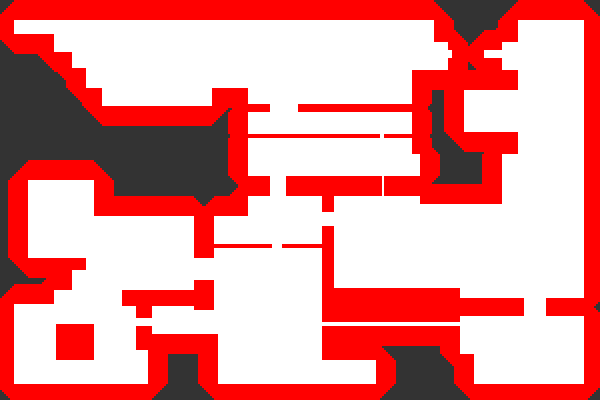

In [41]:
erosion = ndimage.binary_erosion(
    input=a,
    structure=structure,
    iterations=1,
    mask=None,
    border_value=1,
    origin=0,
    brute_force=False
)
show(a, erosion)

## [Closing](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.binary_closing.html)

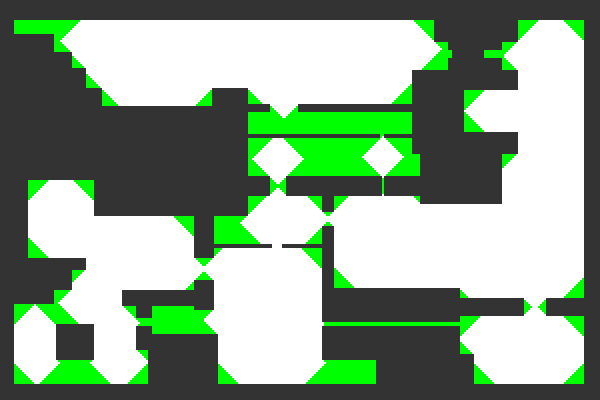

In [44]:
closing = ndimage.binary_closing(
    input=a,
    structure=structure,
    iterations=1,
    origin=0,
    mask=None,
    border_value=1,
    brute_force=False,
)
show(a, closing)

## [Opening](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.binary_opening.html)

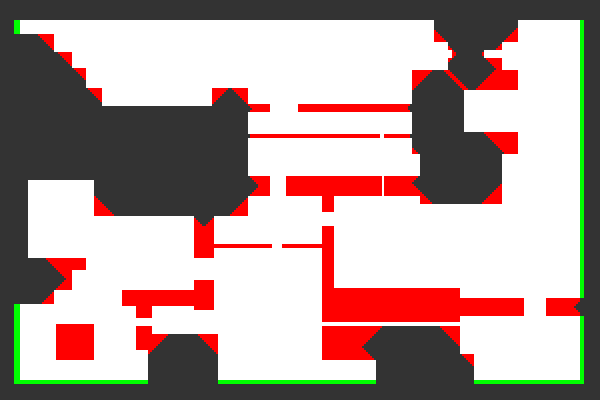

In [45]:
opening = ndimage.binary_opening(
    input=a,
    structure=structure,
    iterations=1,
    origin=0,
    mask=None,
    border_value=1,
    brute_force=False,
)
show(a, opening)

## Propagation

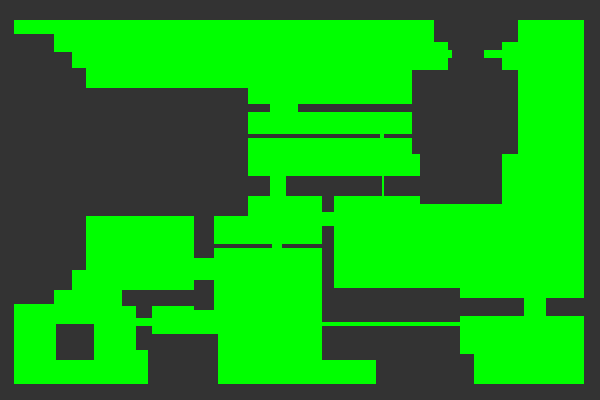

In [24]:
propagation = ndimage.binary_propagation(
    input=a,
    structure=structure,
    origin=0,
    mask=None,
    border_value=0,
)
show(a, propagation)

## Erosion + Propagation

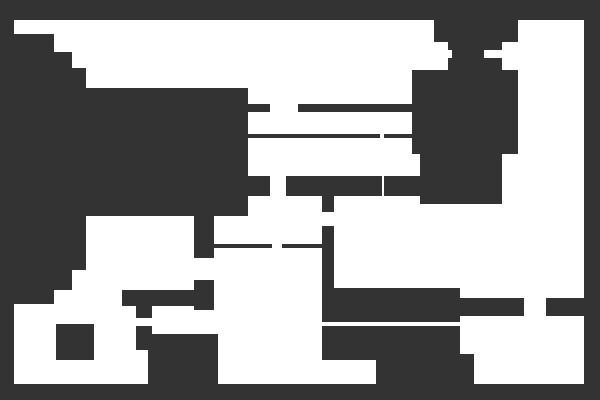

In [25]:
erosion_propagation = ndimage.binary_propagation(
    input=erosion,
    structure=structure,
    origin=0,
    mask=a,
    border_value=0
)
show(a, erosion_propagation)

## Opening + Closing

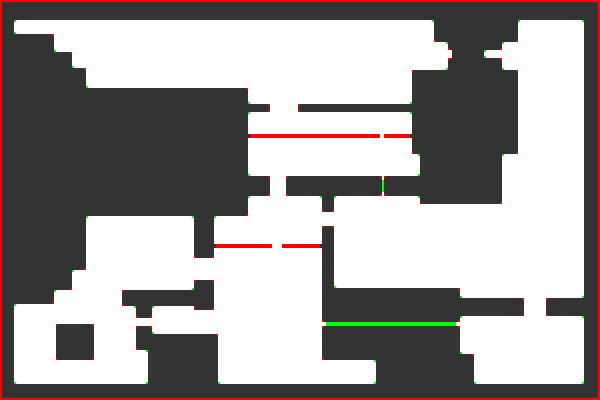

In [26]:
opening_closing = ndimage.binary_closing(
    input=opening,
    structure=structure,
    iterations=1,
    origin=0,
    mask=None,
    border_value=0,
    brute_force=False,
)
show(a, opening_closing)

## Closing + Opening

/var/folders/hj/nj_5zgk10f39m5qgw39hgzlh0000gn/T/ipykernel_21892/889714951.py:48: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(width, height), dpi=dpi or min(width, height)/100)


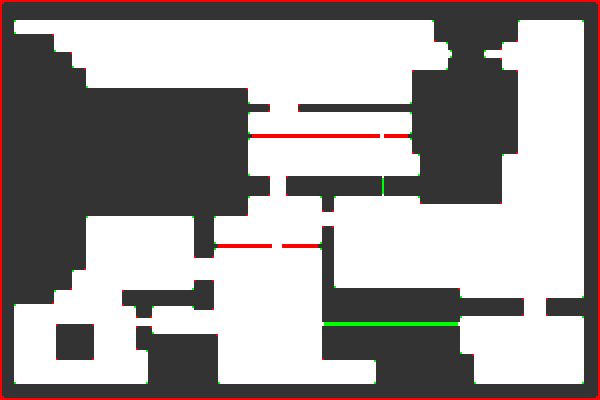

In [27]:
closing_opening = ndimage.binary_opening(
    input=closing,
    structure=structure,
    iterations=1,
    origin=0,
    mask=None,
    border_value=0,
    brute_force=False,
)
show(a, closing_opening)